# EDA – Telco Customer Churn

Utforskande dataanalys inför modelleringen. Datan läses från samma SQLite-databas
som träningen och appen använder. Funktioner för aggregering återanvänds från `src/eda.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # src/ -> repots rot.

import matplotlib.pyplot as plt
import pandas as pd

from src.data import NUMERIC_COLUMNS, TARGET_COLUMN, add_features, clean
from src.db import load_customers
from src.eda import EDA_CATEGORIES, churn_correlations, churn_rate_by

pd.set_option("display.max_columns", None)

## 1. Inläsning

Datan läses från `data/churn.db`, samma källa som `python -m src.train` och appen.

In [2]:
df = load_customers()

print(f"{df.shape[0]} kunder, {df.shape[1]} kolumner")

df.head()

# load_customers() kör SELECT * FROM customers mot SQLite och ger en DataFrame med rådatan,
# innan clean() och add_features(). EDA:n visar först hur datan ser ut, sedan vad
# bearbetningen gör med den.

7043 kunder, 21 kolumner


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Observationer från `head()`:
- `customerID` är identifierare, inte en egenskap. Den ska aldrig in i modellen.
- De flesta ja/nej-kolumner är text, men `SeniorCitizen` är redan 0/1. Därför ligger den bland de numeriska kolumnerna i `src/data.py`.
- Vissa kolumner har ett tredje värde utöver ja/nej, t.ex. `No phone service` i `MultipleLines`. Det gör att kolumnerna inte är rent binära utan behöver one-hot-kodas.
- `tenure` är antal månader som kund. Rad 0 har tenunre 1 och `TotalCharges` = `MonthlyCharges`, vilket stämmer: totalt belopp = månader * månadskostnad.
- `Churn` är målvariablen, `Yes`/`No`. Den mappas till 1/0 i `src/data.py`.

## 2. Första blicken: datatyper och saknade värden

Innan analysen behöver vi veta vilka kolumner som är numeriska, vilka som är kategoriska,
och om det saknas värden.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

Observationer från `info()`:

- Bara tre kolumner är numeriska: `SeniorCitizen`,
  `tenure`, `MonthlyCharges`.
- `TotalCharges` är text trots att den ska vara ett tal.
  Något i kolumnen går alltså inte att tolka som tal.
- Inget värde är null. Men det betyder inte att inget
  saknas, en tom sträng räknas inte som null.

In [4]:
# Vilka värden i TotalCharges går inte att tolka som tal?

as_number = pd.to_numeric(df["TotalCharges"], errors="coerce")
bad = df[as_number.isna()]

print(f"{len(bad)} rader med TotalCharges som inte är tal")
bad[["customerID", "tenure", "MonthlyCharges", "TotalCharges", TARGET_COLUMN]]

11 rader med TotalCharges som inte är tal


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Alla 11 rader har `tenure = 0`: kunder som precis
börjat och ännu inte fakturerats. `TotalCharges` är
en tom sträng, inte ett fel. Ingen av dem har churnat.

Hantering i `src/data.py`:
- `clean()` gör kolumnen numerisk och lämnar dessa
  som `NaN`.
- Pipelinen imputerar dem med medianen.

Alternativet vore att ta bort raderna. Vi behåller
dem: 11 av 7043 påverkar knappt något, och en ny kund
är exakt vad vi ska kunna prediktera på.

## 3. Målvariabeln: hur många churnar?

In [5]:
churn_counts = df[TARGET_COLUMN].value_counts()
churn_share = churn_counts / len(df)
pd.DataFrame({"antal": churn_counts, "andel": churn_share.round(3)})

,antal,andel
Churn,,
No,5174,0.735
Yes,1869,0.265


1869 av 7043 kunder (26,5 %) har churnat. Klasserna
är obalanserade: ungefär tre av fyra stannar.

Det får tre konsekvenser för modelleringen:
- Accuracy räcker inte. En modell som alltid
  gissar "No" får 73,5 % rätt utan att hitta en enda
  churnare. Därför utvärderar vi med precision,
  recall, F1 och ROC-AUC.
- class_weight="balanced" i src/models.py
  gör att en missad churnare kostar mer vid träning.
- Stratifierad split i src/train.py ger samma
  churn-andel i train, validation och test.

## 4. Kategoriska variabler mot churn

Churn-andel per kategori. Kolumnerna kommer från
EDA_CATEGORIES i src/eda.py.

In [6]:
churn_rate_by(df, "Contract")

,Contract,churn_andel,antal_kunder
0,Month-to-month,0.427097,3875
1,One year,0.112695,1473
2,Two year,0.028319,1695


- Avtalsform är en stark signal. Kunder med månadsavtal churnar i 42,7 % av fallen, kunder med ettårsavtal i 11,3 % och kunder med tvåårsavtal i 2,8 %. Ju längre bindningstid, desto lägre risk.
- Månadskunderna är också den största gruppen (3875 kunder), så det är där flest churnare finns.

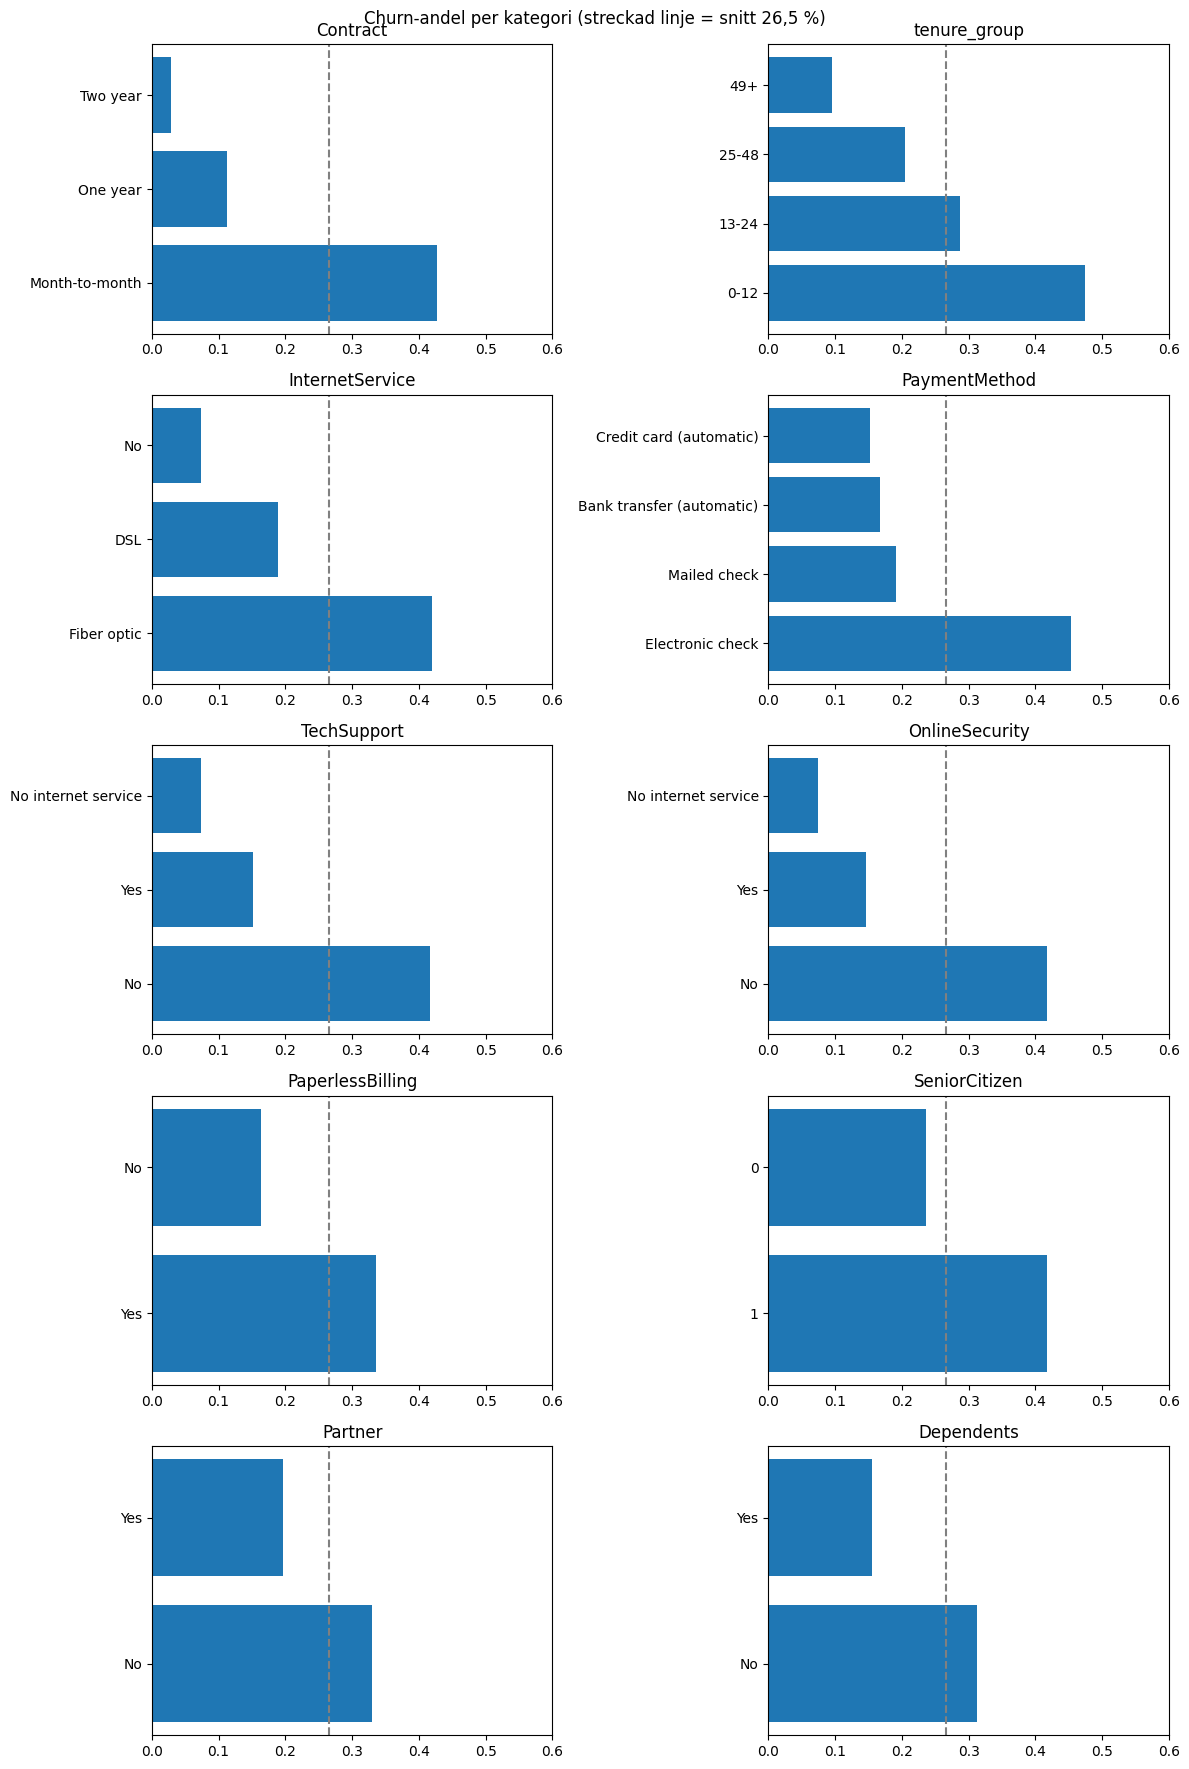

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(12, 18))
for ax, column in zip(axes.flat, EDA_CATEGORIES, strict=True):
    rates = churn_rate_by(df, column)
    ax.barh(rates[column].astype(str), rates["churn_andel"])
    ax.set_title(column)
    ax.set_xlim(0, 0.6)
    ax.axvline(churn_share["Yes"], color="grey", linestyle="--")
fig.suptitle("Churn-andel per kategori (streckad linje = snitt 26,5 %)")
fig.tight_layout()
plt.show()

Fyra kolumner har en kategori med churn över 40 %:

- Contract: månadsavtal 42,7 %.
- tenure_group: första året 47 %. Andelen sjunker
  sedan för varje grupp, till under 10 % efter fyra år.
- InternetService: fiber 42 %, mot 19 % för DSL och
  7 % för kunder utan internet.
- PaymentMethod: e-check 45 %, mot 15-19 % för övriga.
  De automatiska betalsätten har lägst churn.

TechSupport och OnlineSecurity visar samma mönster:
kunder som har internet men saknar tjänsten churnar
i över 40 %, kunder som har tjänsten i cirka 15 %.
Tilläggstjänster verkar alltså binda kunden.

Svagare men tydliga skillnader finns för
PaperlessBilling, SeniorCitizen, Partner och
Dependents. Kunder utan partner eller barn, äldre
kunder och kunder med pappersfri faktura churnar
något mer än snittet.

Sammantaget: churn är koncentrerad till nya kunder
med månadsavtal, fiber, e-check och få tilläggstjänster.

## 5. Numeriska variabler mot churn

In [8]:
clean_df = clean(df)
clean_df["churn"] = (df[TARGET_COLUMN] == "Yes").astype(int)
clean_df.groupby("churn")[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T.round(1)

# clean() gör TotalCharges numerisk, sedan lägger vi på en 0/1-kolumn för churn och jämför fördelningen av de tre beloppskolumnerna för de som stannat respektive lämnat.
# describe() ger antal, medel, spridning och kvartiler medan T vänder tabellen så den blir läsbar.

churn                      0       1
tenure         count  5174.0  1869.0
               mean     37.6    18.0
               std      24.1    19.5
               min       0.0     1.0
               25%      15.0     2.0
               50%      38.0    10.0
               75%      61.0    29.0
               max      72.0    72.0
MonthlyCharges count  5174.0  1869.0
               mean     61.3    74.4
               std      31.1    24.7
               min      18.2    18.8
               25%      25.1    56.2
               50%      64.4    79.6
               75%      88.4    94.2
               max     118.8   118.4
TotalCharges   count  5163.0  1869.0
               mean   2555.3  1531.8
               std    2329.5  1890.8
               min      18.8    18.8
               25%     577.8   134.5
               50%    1683.6   703.6
               75%    4264.1  2331.3
               max    8672.4  8684.8

Tabellen jämför fördelningen av de tre numeriska
kolumnerna för kunder som stannat (0) och churnat (1).

Tenure. Här är skillnaden störst. Halva gruppen som
churnat gjorde det inom 10 månader, och en fjärdedel
inom 2 månader. Bland de som stannat har hälften varit
kunder i över 38 månader. Båda grupperna når max 72,
så datan täcker sex år, men churnarna ligger nästan
helt i början av den perioden. Churn är alltså i
första hand något som sker tidigt i kundrelationen.
Klarar kunden det första året sjunker risken kraftigt,
vilket stämmer med grafen för tenure_group ovan.

MonthlyCharges. Churnare betalar mer per månad, median
79,6 mot 64,4, men det intressanta är spridningen.
Bland de som stannar ligger den nedre kvartilen på
25,1, alltså finns många billiga kunder som stannar.
Bland churnarna ligger den på 56,2. Kunder med låg
månadskostnad churnar sällan. Det är i praktiken
kunder med bara telefoni och utan internet, vilket
förklarar den låga andelen för InternetService = No.
Churn är alltså inte bara ett prisproblem utan
kopplat till vilken typ av tjänst kunden har.

TotalCharges. Churnare har lägre totalt belopp trots
högre månadskostnad. Det är ingen egen signal utan en
följd av kort tenure: totalt belopp är ungefär tenure
gånger MonthlyCharges. Kolumnen är därför starkt
korrelerad med tenure, något vi kontrollerar i
avsnitt 6. För trädmodeller spelar det liten roll,
för logistisk regression kan det göra koefficienterna
svårare att tolka.

Count för TotalCharges är 5163, inte 5174. Det är de
11 nya kunderna som blivit NaN efter clean() och som
pipelinen imputerar med medianen.

Slutsats för modelleringen: tenure och MonthlyCharges
är de två viktigaste numeriska variablerna, och de
fångar olika saker: hur länge kunden funnits och vad
kunden har för tjänst. TotalCharges tillför lite
utöver dem.

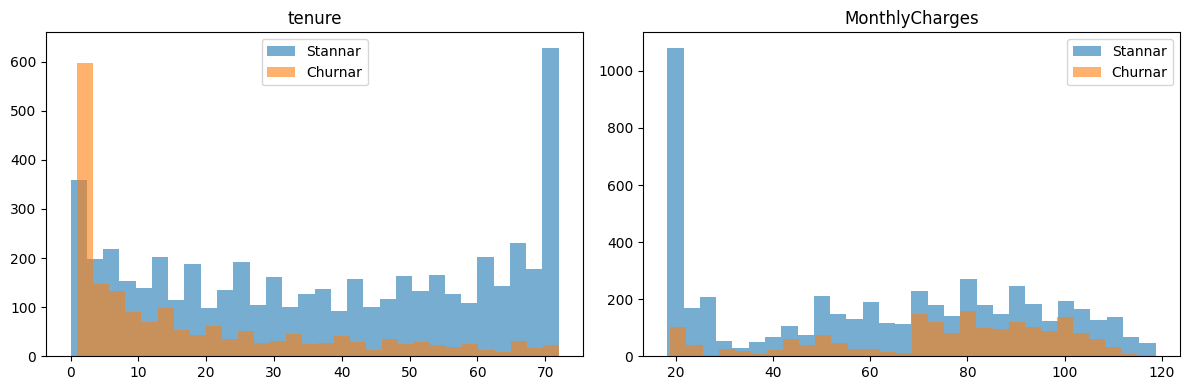

In [9]:
# Tabellen ovan visar siffror, en graf visar formen på fördelningen. Nu blir mönstret lite mer uppenbart.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column in zip(axes, ["tenure", "MonthlyCharges"], strict=True):
    for value, label in [(0, "Stannar"), (1, "Churnar")]:
        subset = clean_df.loc[clean_df["churn"] == value, column]
        ax.hist(subset, bins=30, alpha=0.6, label=label)
    ax.set_title(column)
    ax.legend()
fig.tight_layout()
plt.show()

Tenure. Churnarna (orange) har en hög topp vid 1-2
månader och avtar sedan snabbt. De som stannar har
i stället två toppar: en vid 0-5 månader (nya kunder
som ännu inte hunnit lämna) och en vid 70-72 månader
(långvariga kunder). Datan slutar vid 72 månader,
så den högra toppen är alla som funnits sedan
mätperiodens början. Mellan topparna är fördelningen
ungefär platt. Bilden bekräftar att churn framför
allt inträffar de första månaderna.

MonthlyCharges. De som stannar har en mycket hög
topp kring 20, vilket är kunder med enbart telefoni.
Nästan inga churnare finns där. Churnarna ligger i
stället samlade mellan 70 och 105, det prisintervall
där fiberkunder hamnar. Fördelningen för churn följer
alltså tjänstetypen snarare än priset i sig.

De två variablerna skiljer grupperna åt på olika
sätt: tenure genom när i kundrelationen kunden
befinner sig, MonthlyCharges genom vilken tjänst
kunden har. Det gör dem till bra komplement i
modellen.